# Series Transformations

This notebook outlines how to use transformations to customize time series models using scalecast. This example is not created to find the perfect model for this particular series--only ARIMA model classes are tried before the last section and some of these transformations are not needed in ARIMA since it has some native transforming operations. It is meant to only show the ease and flexibility of transforming series and reverting results so that point forecasts, **using any available model class**, are always easily accessible using this framework.

Read the [documentation](https://scalecast.readthedocs.io/en/latest/Forecaster/SeriesTransformer.html). See the [blog post](https://medium.com/towards-data-science/time-series-transformations-and-reverting-made-easy-f4f768c18f63).

In [1]:
import matplotlib.pyplot as plt
import pandas_datareader as pdr
from scalecast.SeriesTransformer import SeriesTransformer
from scalecast.Pipeline import Pipeline
from scalecast.auxmodels import auto_arima
from scalecast.util import Forecaster_with_missing_vals, find_optimal_transformation
from scalecast import GridGenerator

In [2]:
def transform_forecast_arima(f,call_me):
    """ applies an auto-arima model on the series (in its given form) and prints out the selected order. 
    only non-seasonal models are tried.
    """
    auto_arima(f,call_me=call_me)
    print('ARIMA order selected: {}'.format(f.history[call_me]['HyperParams']))

## Download Data and Set Object Parameters
- Forecast horizon: 24
- Test length: 24

In [3]:
df = pdr.get_data_fred(
    'HOUSTNSA',start='1959-01-01',
    end = '2025-12-31',
)

f = Forecaster_with_missing_vals(y=df['HOUSTNSA'],current_dates=df.index,future_dates=24,test_length=24)

## Initialize the SeriesTransformer Object

This object applies all available transformations and reverts results.

In [4]:
transformer = SeriesTransformer(f, deepcopy=True)

In [5]:
transformer

SeriesTransformer(
Forecaster(
    DateStartActuals=1959-01-01T00:00:00.000000000
    DateEndActuals=2025-12-01T00:00:00.000000000
    Freq=MS
    N_actuals=804
    ForecastLength=24
    Xvars=[]
    TestLength=24
    ValidationMetric=rmse
    ForecastsEvaluated=[]
    CILevel=None
    CurrentEstimator=mlr
    GridsFile=Grids
)
)

## Forecast on Original Series

In [6]:
transform_forecast_arima(f,'arima_orig_series')

ARIMA order selected: {'order': (1, 1, 0), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


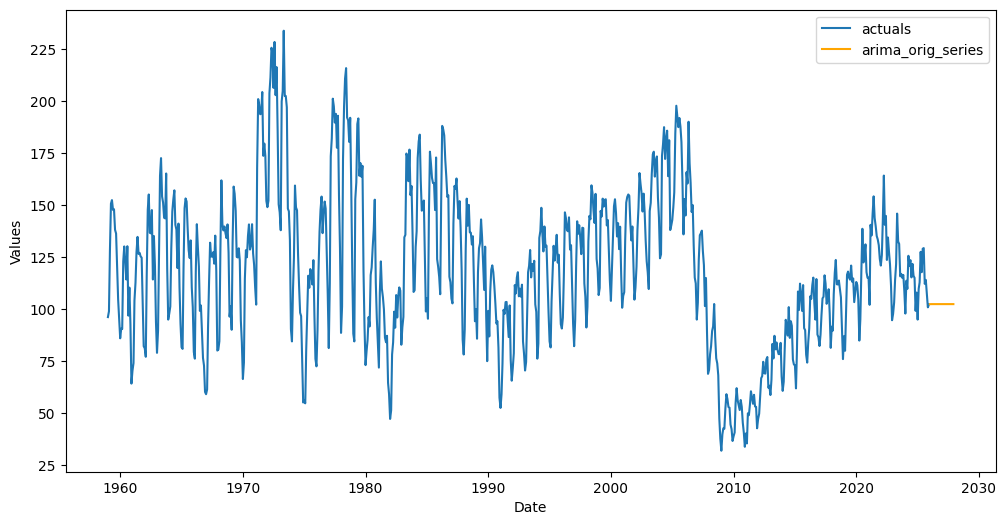

In [7]:
# plot results
f.plot()
plt.show()

## Forecast on Series First Diff

In [8]:
f = transformer.DiffTransform(1)

In [9]:
transform_forecast_arima(f,'arima_1diff')

ARIMA order selected: {'order': (1, 0, 0), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


The order selected is the same as the original series, except that the middle term (integration, or i) is set to 0. This is as expected. When i is 0, ARIMA is taking a first difference on the series under-the-hood. So the resulting point forecasts between this and the first applied model should be equal to one another.

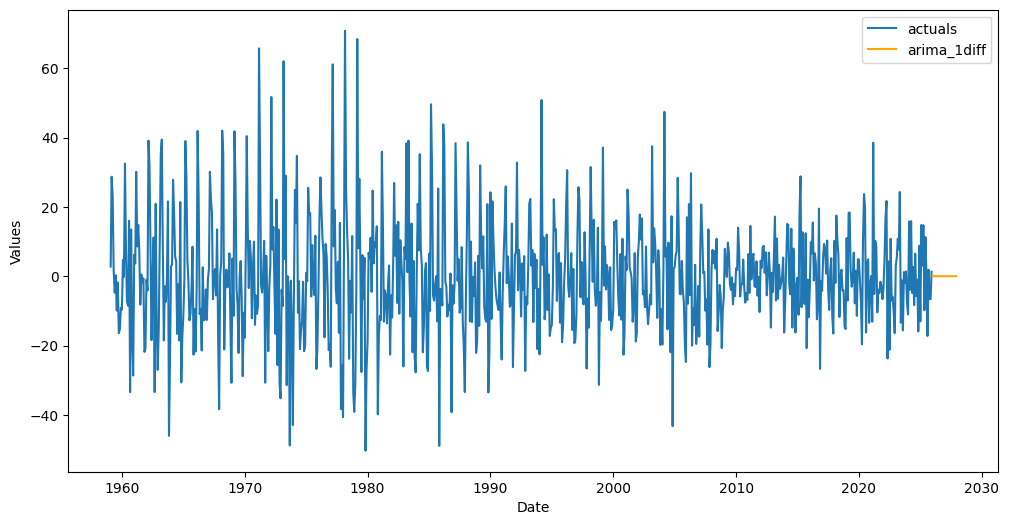

In [10]:
f.plot(models='arima_1diff')
plt.show()

Here is the plot of the series before it has been reverted.

In [11]:
f = transformer.DiffRevert(1, exclude_models = [
    m for m in f.history if m != 'arima_1diff' # only revert the last model called
])

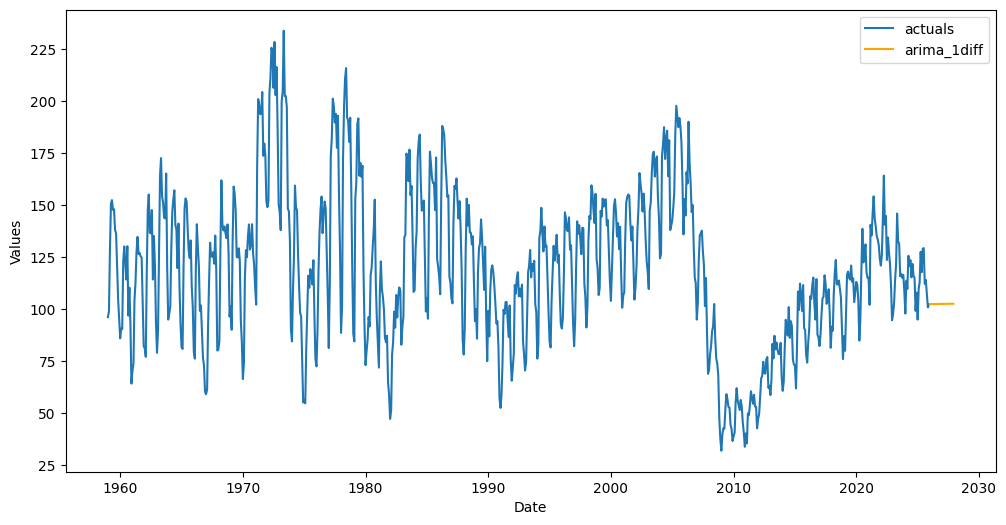

In [12]:
f.plot()
plt.show()

After reverting the series, we see the series is back to its original form and the results of the first two ARIMA models are exactly the same, as expected.

Scalecast also has a [method](https://scalecast.readthedocs.io/en/latest/Forecaster/Forecaster.html#src.scalecast.Forecaster.Forecaster.diff) that can be used for taking first differences (and reverting results) on series without the use of `SeriesTransformer`. Either approach can be used for equivalent results, but they should not be combined.

## Forecast on First Seasonal Diff

To add seasonal adjustments to the series, we can take a seasonal difference. Since we are using monthly data, this will difference every 12th observation. Reverting is just as easy as reverting a first difference.

In [13]:
f = transformer.DiffTransform(12) # difference every 12th obs

In [14]:
transform_forecast_arima(f,'arima_1diff_seas')

ARIMA order selected: {'order': (1, 0, 2), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


The ARIMA model selected 3 autoregressive terms, but no moving average terms. This model is equivalent to a (3, 0, 0)x(0, 1, 0, 12) ARIMA model.

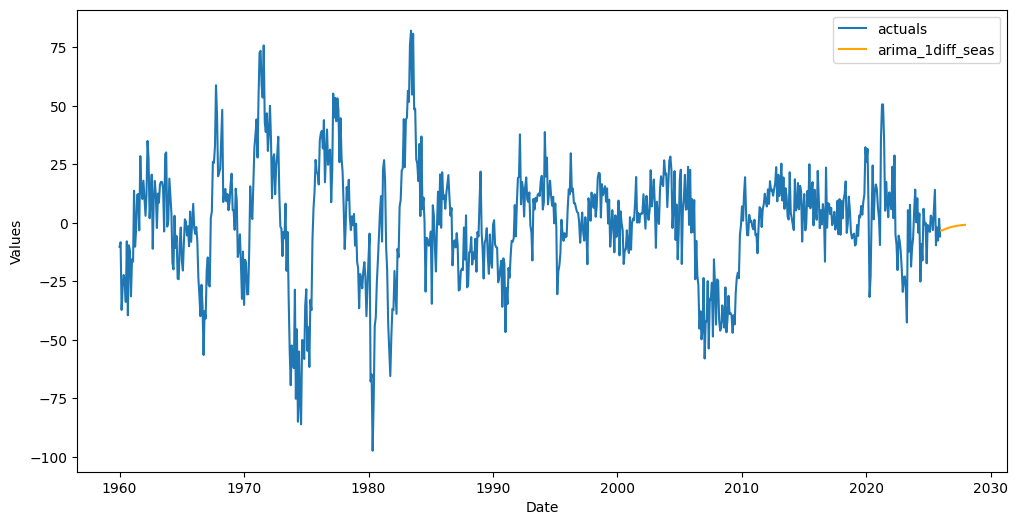

In [15]:
f.plot(models='arima_1diff_seas')
plt.show()

The point predictions do not appear very dynamic in the seasonally differenced series, but when we revert this transformation, the forecast appears believable.

In [16]:
f = transformer.DiffRevert(12, exclude_models = [
    m for m in f.history if m != 'arima_1diff_seas'
])

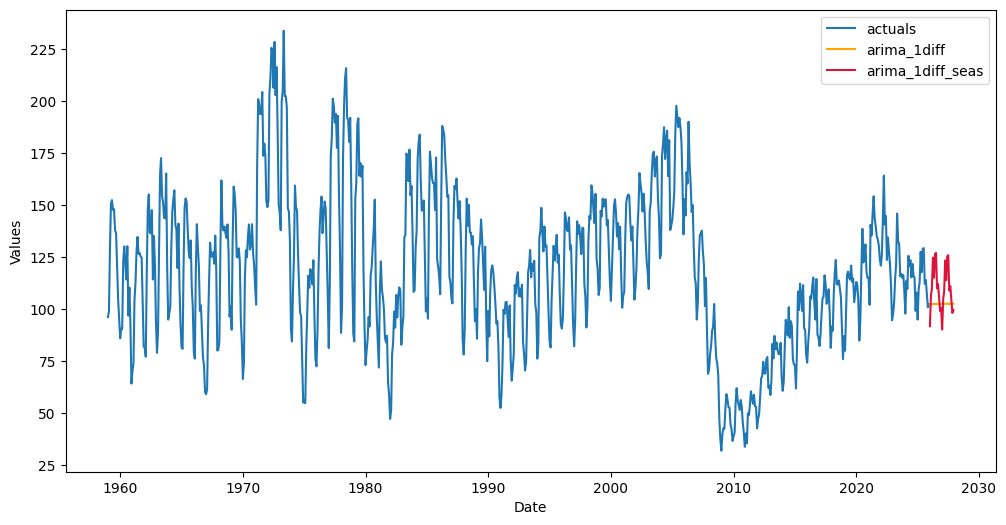

In [17]:
f.plot()
plt.show()

## Forecast on Second Diff

You can stack several transformations on top of each other, such as two first differences to get to a series second difference. Second differences really accentuate any underlying trend in the data and resulting forecasts (such as the one shown here) can explode upwards or downwards dramatically. The more differences you stack, the more likely this is to happen. Even so, stacking as many differences as you want is possible.

In [18]:
f = transformer.DiffTransform(1)
f = transformer.DiffTransform(1)

In [19]:
transform_forecast_arima(f,'arima_2diff')

ARIMA order selected: {'order': (5, 0, 0), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


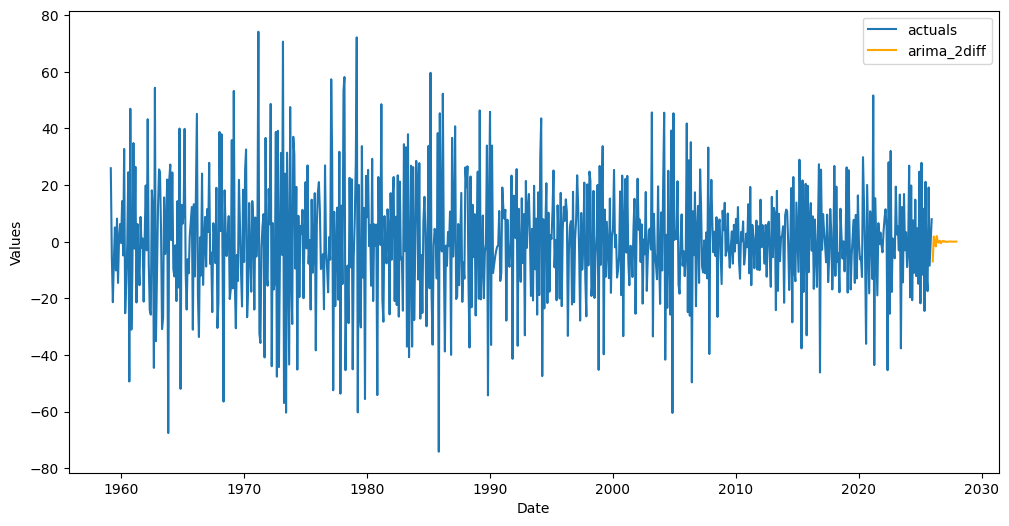

In [20]:
f.plot(models='arima_2diff')
plt.show()

In [21]:
f = transformer.DiffRevert(1, exclude_models = [m for m in f.history if m != 'arima_2diff'])
f = transformer.DiffRevert(1, exclude_models = [m for m in f.history if m != 'arima_2diff'])

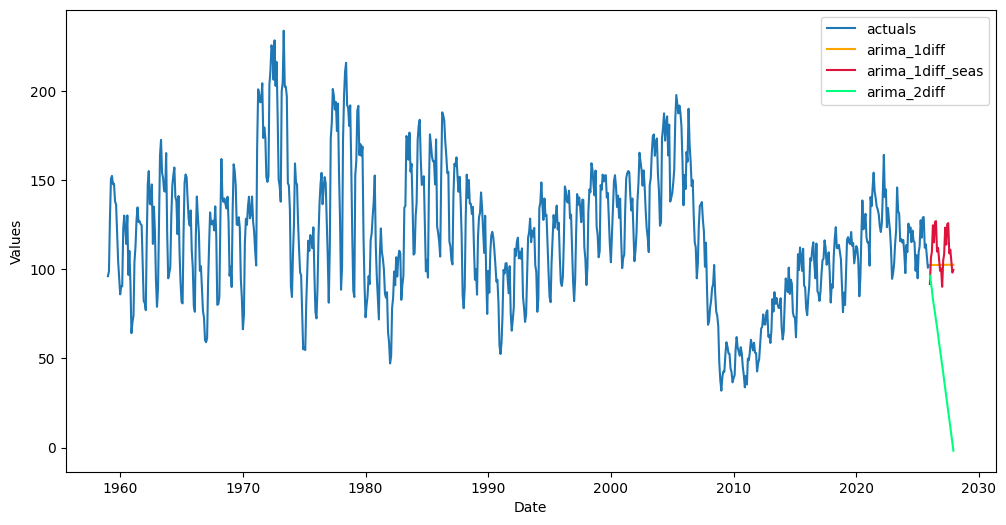

In [22]:
f.plot()
plt.show()

This forecast looks so bad that we can consider deleting it out of the object's history by using the `pop` method.

In [23]:
f.pop('arima_2diff')

Forecaster(
    DateStartActuals=1959-01-01T00:00:00.000000000
    DateEndActuals=2025-12-01T00:00:00.000000000
    Freq=MS
    N_actuals=804
    ForecastLength=24
    Xvars=[]
    TestLength=24
    ValidationMetric=rmse
    ForecastsEvaluated=['arima_1diff', 'arima_1diff_seas']
    CILevel=None
    CurrentEstimator=arima
    GridsFile=Grids
)

## Forecast on Detrended Series

Detrending is commonly used in machine learning to deal with non-stationary data while preserving more information about the series than a first difference would let you. There are many options for detrending using scalecast.

### Default Detrending

In [24]:
# below are the function's default args
f = transformer.DetrendTransform(
    poly_order=1, # the linear function's underlying order
    ln_trend=False, # whether to use a natural log of the trend to accentuate trends
    seasonal_lags=0, # seasonal trend lags make seasonal detrending possible
    m='auto', # how many periods complete one seasonal cycle
    fit_intercept=True, # intercept in the underlying linear model
    train_only=False, # whether to hold out the test set when estimating the linear function to prevent overfitting
)

In [25]:
transform_forecast_arima(f,'arima_detrended')

ARIMA order selected: {'order': (5, 0, 2), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


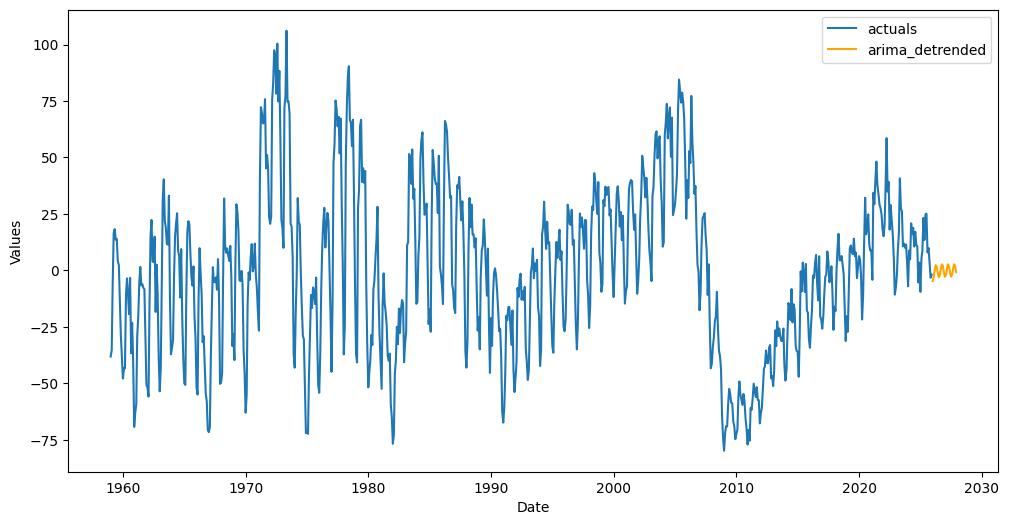

In [26]:
f.plot(models='arima_detrended')
plt.show()

The detrended series doesn't look much different than the original series, since this series was already pretty stationary. Looking at the vertical axis, however, you can see that the values have been transformed.

In [27]:
f = transformer.DetrendRevert(exclude_models = [
    m for m in f.history if m != 'arima_detrended'
])

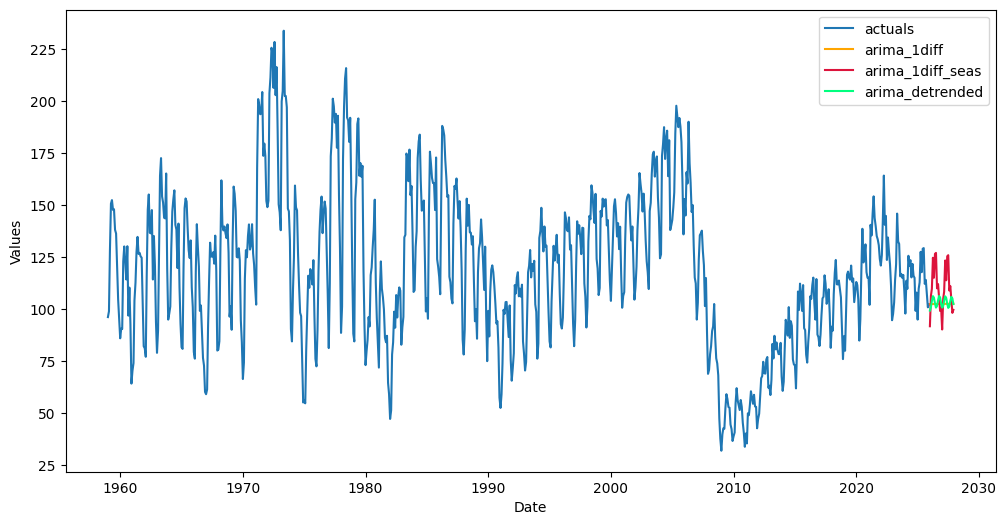

In [28]:
f.plot()
plt.show()

Below are explored several more detrending options.

### Quadratic Detrending

In [29]:
f = transformer.DetrendTransform(poly_order=2)

In [30]:
transform_forecast_arima(f,'arima_detrended_poly2')

ARIMA order selected: {'order': (5, 0, 2), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


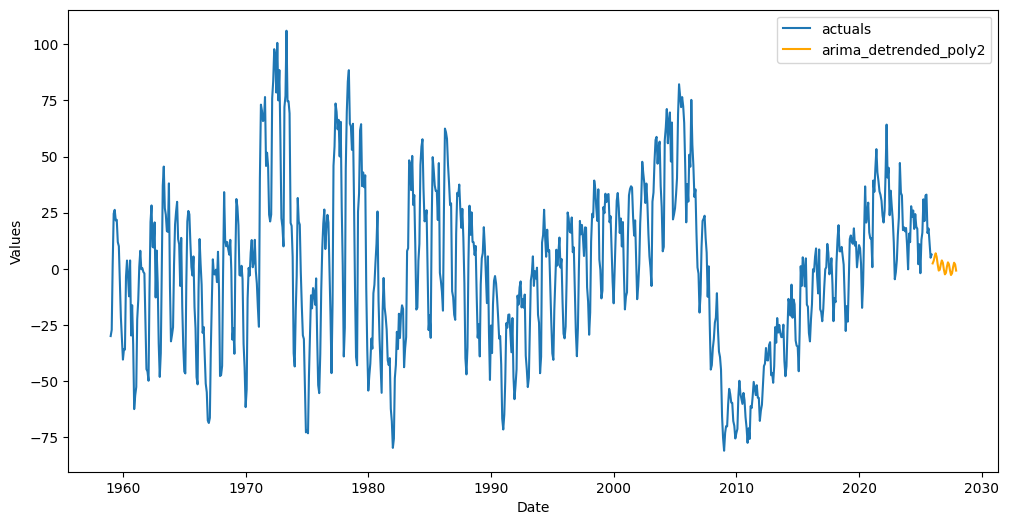

In [31]:
f.plot(models='arima_detrended_poly2')
plt.show()

In [32]:
f = transformer.DetrendRevert(exclude_models = [
    m for m in f.history if m != 'arima_detrended_poly2'
])

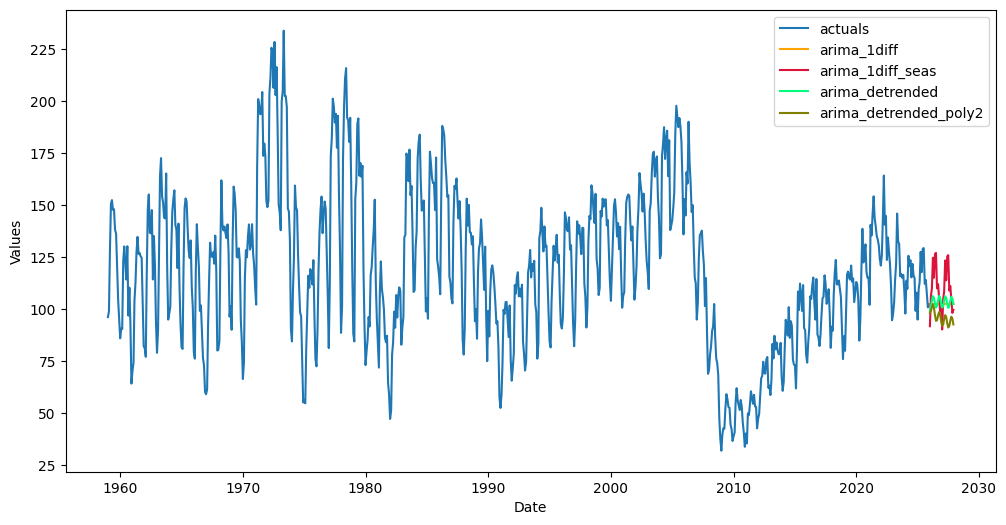

In [33]:
f.plot()
plt.show()

### Logarithmic Detrending

In [34]:
f = transformer.DetrendTransform(ln_trend=True)

In [35]:
transform_forecast_arima(f,'arima_detrended_ln')

ARIMA order selected: {'order': (1, 1, 0), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


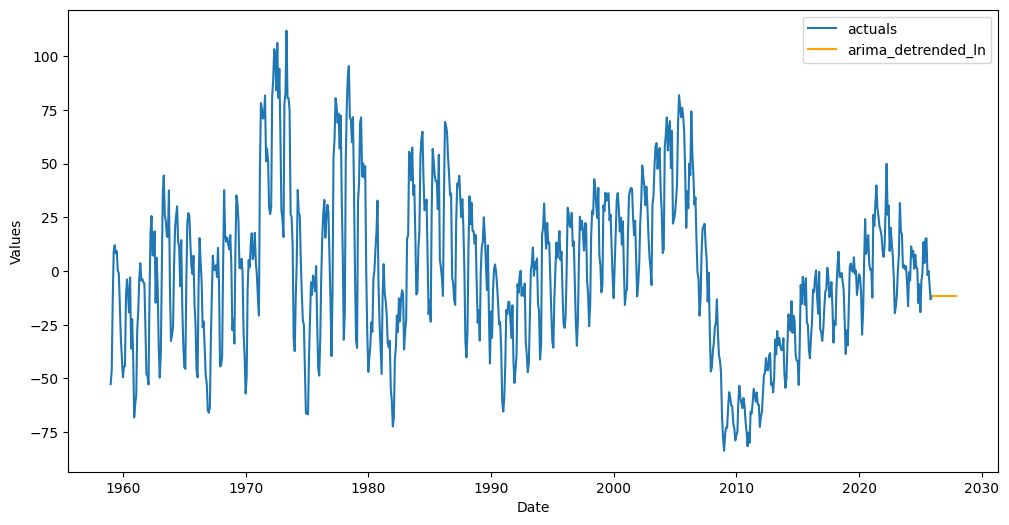

In [36]:
f.plot(models='arima_detrended_ln')
plt.show()

In [37]:
f = transformer.DetrendRevert(exclude_models = [
    m for m in f.history if m != 'arima_detrended_ln'
])

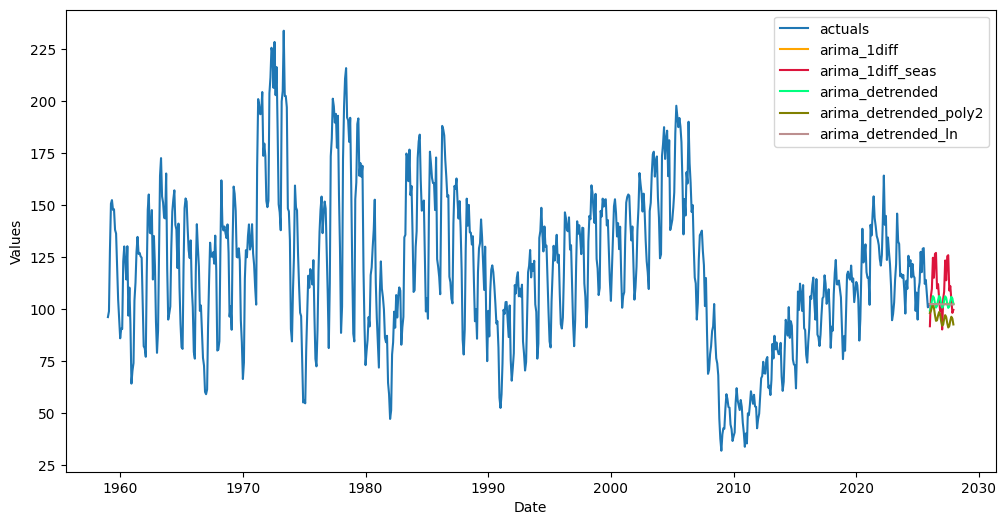

In [38]:
f.plot()
plt.show()

### Seasonal Detrending

In [39]:
f = transformer.DetrendTransform(seasonal_lags = 1, m = 12)

/Users/uger7/Documents/GitHub/scalecast/src/scalecast/_Forecaster_parent.py:1406: Warning: With the introduction of 12 lags, there are now more n/a observations than are introduced with 0 autoregressive terms. This can cause failures in models. Try running chop_from_back(12) but be careful if series transformations were taken, especially, DiffTransform().
  warnings.warn(


In [40]:
transform_forecast_arima(f,'arima_detrended_seas')

ARIMA order selected: {'order': (5, 0, 2), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


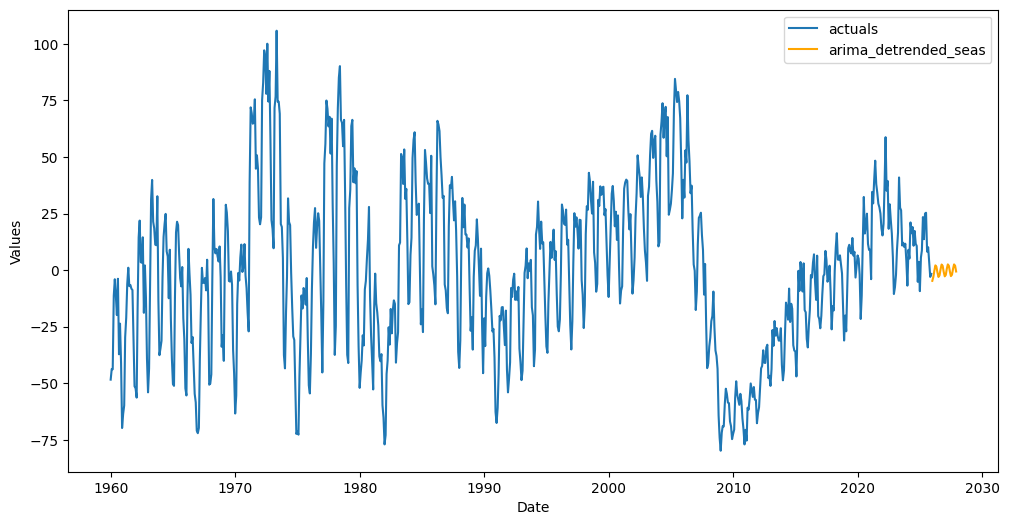

In [41]:
f.plot(models='arima_detrended_seas')
plt.show()

In [42]:
f = transformer.DetrendRevert(exclude_models = [
    m for m in f.history if m != 'arima_detrended_seas'
])

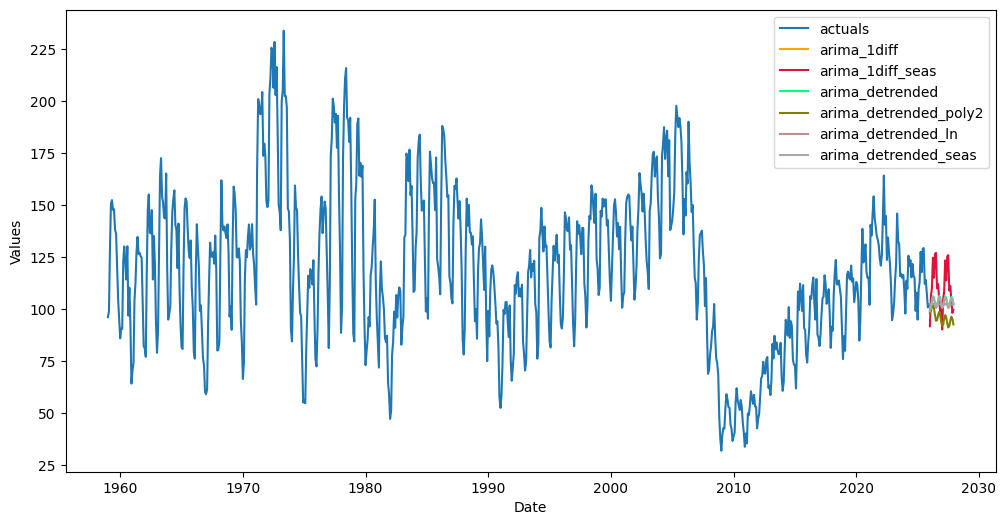

In [43]:
f.plot()
plt.show()

## Boxcox Transform

Arbitrary transformation functions can be passed to the scalecast framework. Below, we explore how using a boxcox transformation with a lambda of 0.5.

In [44]:
def boxcox_tr(x,lmbda):
    return [(i**lmbda - 1) / lmbda for i in x] if lmbda != 0 else [np.log(i) for i in x]
def boxcox_re(x,lmbda):
    return [(i*lmbda + 1)**(1/lmbda) for i in x] if lmbda != 0 else [np.exp(i) for i in x]

In [45]:
f = transformer.Transform(boxcox_tr, lmbda = .5)

In [46]:
transform_forecast_arima(f,'arima_boxcox')

ARIMA order selected: {'order': (1, 1, 0), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


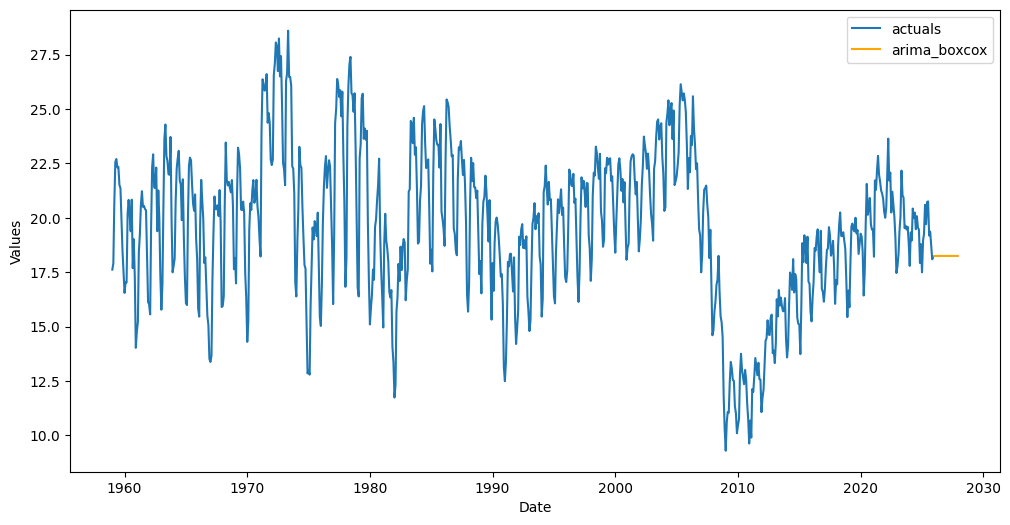

In [47]:
f.plot(models='arima_boxcox')
plt.show()

In [48]:
f = transformer.Revert(boxcox_re, lmbda = 0.5, exclude_models = [
    m for m in f.history if m != 'arima_boxcox'
])

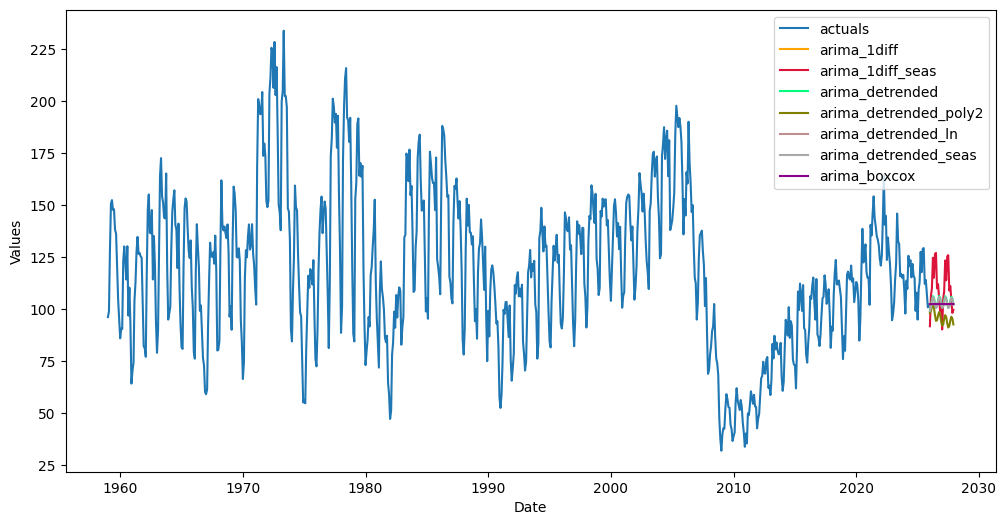

In [49]:
f.plot()
plt.show()

## Scale

### Standard

In [50]:
f = transformer.ScaleTransform()

In [51]:
transform_forecast_arima(f,'arima_scaled')

ARIMA order selected: {'order': (1, 1, 0), 'seasonal_order': (0, 0, 0, 0), 'trend': None}


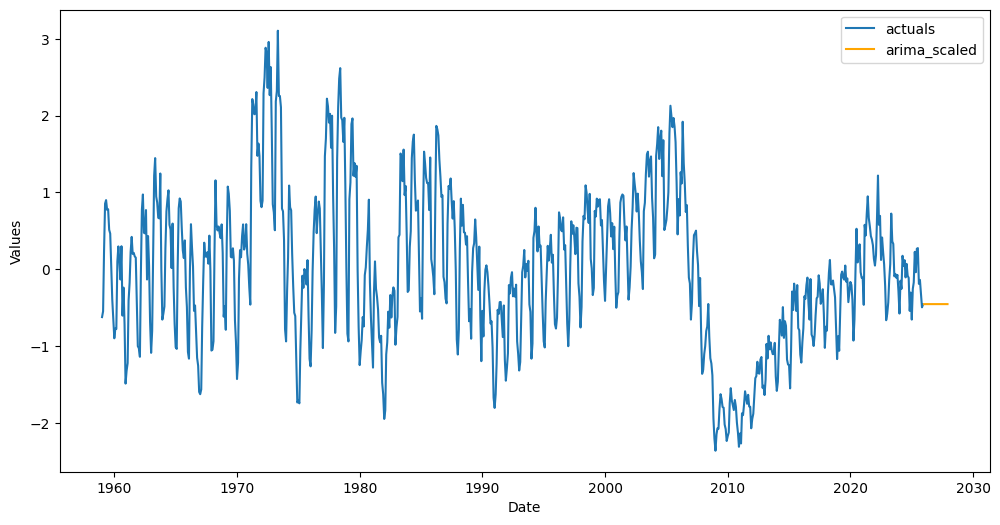

In [52]:
f.plot(models='arima_scaled')
plt.show()

In [53]:
f = transformer.ScaleRevert(exclude_models = [
    m for m in f.history if m != 'arima_scaled'
])

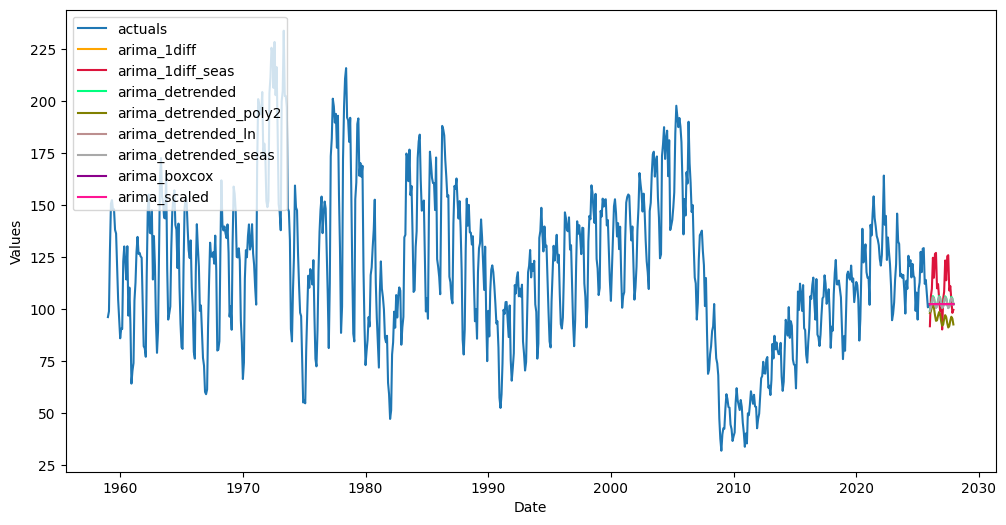

In [54]:
f.plot()
plt.legend(loc='upper left')
plt.show()

[MinMax scaling](https://scalecast.readthedocs.io/en/latest/Forecaster/SeriesTransformer.html#src.scalecast.SeriesTransformer.SeriesTransformer.MinMaxTransform) is also available.

## Compare All Models by Test-Set Performance

We can now see which models returned the best performance on our test set, which is the last 24 observations in the series. See also [backtesting](https://scalecast.readthedocs.io/en/latest/Forecaster/Forecaster.html#src.scalecast.Forecaster.Forecaster.backtest).

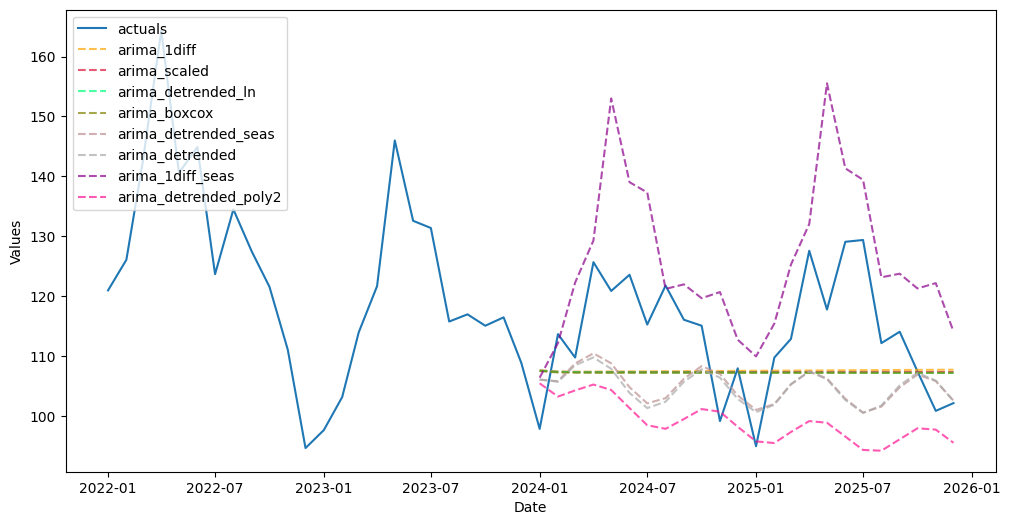

In [55]:
f.plot_test_set(include_train = 48, order_by = 'TestSetRMSE')
plt.legend(loc='upper left')
plt.show()

In [56]:
results = f.export('model_summaries',determine_best_by='TestSetRMSE')
results[['ModelNickname','TestSetRMSE','InSampleRMSE']]

,ModelNickname,TestSetRMSE,InSampleRMSE
0,arima_1diff,11.440134,36.274985
0,arima_scaled,11.538118,16.401508
0,arima_detrended_ln,11.583378,16.491218
0,arima_boxcox,11.609816,16.711288
0,arima_detrended_seas,12.967659,14.359457
0,arima_detrended,13.200948,14.181646
0,arima_1diff_seas,15.338337,13.429508
0,arima_detrended_poly2,17.646658,14.077678


In spite of the fact that it doesn't look like the most believable forecast over the forecast horizon, the best-performing forecast (using RMSE as the metric) is the ARIMA on the boxcox-transformed series. You can choose to use any of these forecasts and don't have to base the decision on the test-set performance.

The arima_1diff model had poor in-sample performance. Let's plot the fitted values to see why that may be.

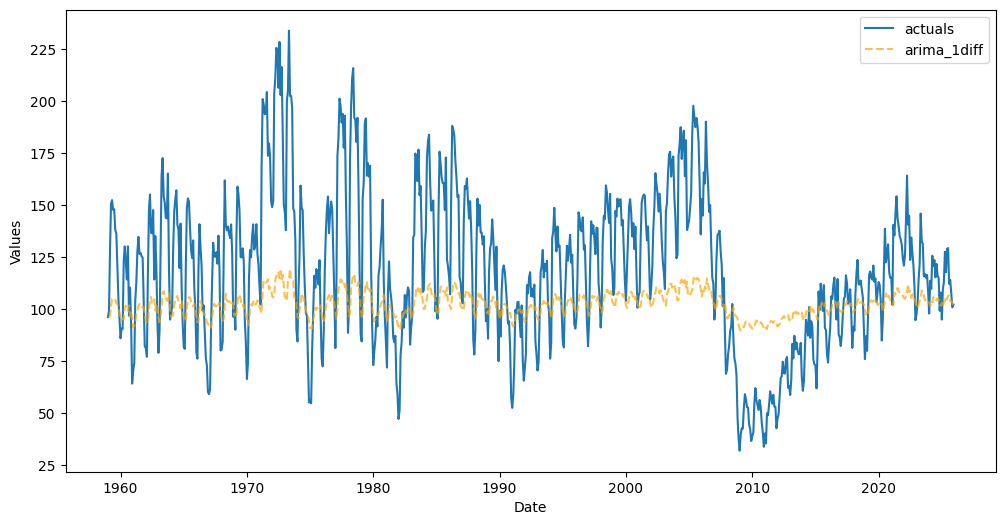

In [57]:
f.plot_fitted(models='arima_1diff')
plt.show()

Undifferencing forecasts can cause some distortion in the resulting fitted values and in the forecast the longer the horizon that is being undifferenced. That appears to be what happened here.

## Automatically Find the Optimal Set of Transformations

Scalecast provides a function that iterates through many transformations and monitors an out-of-sample metric to attempt to find an optimal transformation combination. The default parameters of the function are given below.

In [58]:
# reload the object
df = pdr.get_data_fred('HOUSTNSA',start='1959-01-01',end = '2022-12-31')
f = Forecaster_with_missing_vals(y=df['HOUSTNSA'],current_dates=df.index,future_dates=24,test_length=24)

In [59]:
transformer, reverter = find_optimal_transformation(
    f, # Forecaster object to try the transformations on
    estimator='mlr', # model used to evaluate each transformation
    monitor='rmse', # out-of-sample metric to monitor
    lags='auto', # uses the length of the test set
    try_order = ['detrend','boxcox','first_diff','first_seasonal_diff','scale'], # order of transformations to try
    boxcox_lambdas = [-0.5,0,0.5], # box-cox lambas
    detrend_kwargs = [{'poly_order':1},{'poly_order':2}], # detrender transform kwargs (tries as many detrenders as the length of this list)
    scale_type = ['Scale','MinMax'], # scale transformers to try
    return_train_only = False, # whether to hold out the test-set when setting the scale parameters
    m='auto', # the seasonal length to try for the first_seasonal_diff transformer 
)

Below shows what set of transformations were chosen.

In [60]:
reverter

Reverter(
  reverters = [
    ('DiffRevert', 12),
    ('DiffRevert', 1)
  ],
  base_transformer = Transformer(
  transformers = [
    ('DiffTransform', 1),
    ('DiffTransform', 12)
  ]
)
)

It is very important that revert functions are called in the opposite as their corresponding transform functions, otherwise model results will devolve into nonsense. The above transformer and reverter objects make sure this is done automatically.

## Stack Transformations in a Pipeline

Using the `Pipeline` object in scalecast, easily maintained code can be implemented with transformation and revert functions. See the [documentation](https://scalecast.readthedocs.io/en/latest/Forecaster/Pipeline.html).

Now, instead of using only ARIMA, we can also compare results with ML models--ElasticNet, XGBoost, and KNN. We use elasticnet to find the optimal set of transformations--this model class can lead to better results on most series in my opinion.

In [61]:
GridGenerator.get_example_grids()
transformer, reverter = find_optimal_transformation(f, estimator='elasticnet')

In [62]:
def forecaster(f):
    models = ['elasticnet','xgboost','knn']
    auto_arima(f)
    f.auto_Xvar_select(estimator='elasticnet', cross_validate=True)
    f.tune_test_forecast(models, cross_validate=True,limit_grid_size=.2)

In [63]:
pipeline = Pipeline(
    steps = [
        ('Transform',transformer),
        ('Forecast',forecaster),
        ('Revert',reverter),
    ],
)

f = pipeline.fit_predict(f)

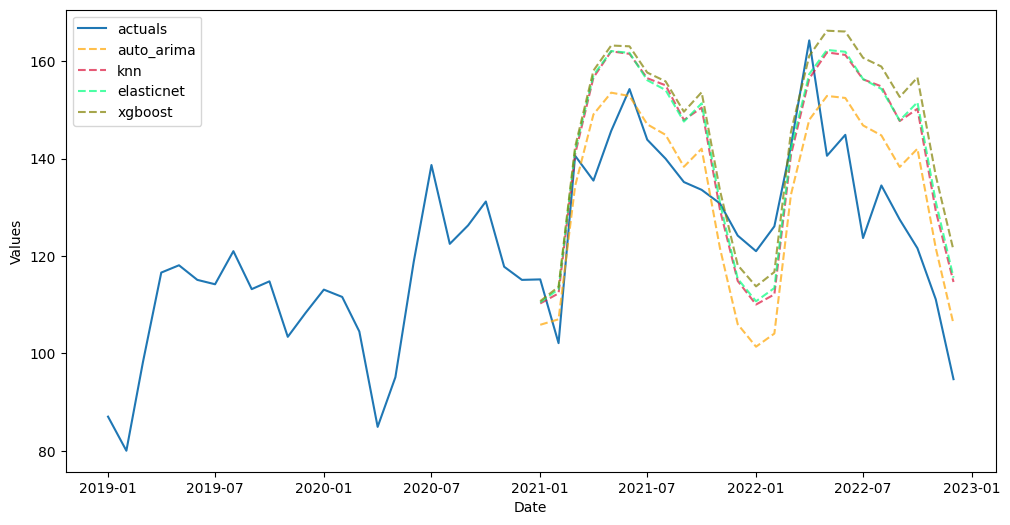

In [64]:
f.plot_test_set(include_train = 48, order_by = 'TestSetRMSE')
plt.legend(loc='upper left')
plt.show()

In [65]:
results = f.export('model_summaries',determine_best_by='TestSetRMSE')
results[['ModelNickname','TestSetRMSE','InSampleRMSE']]

,ModelNickname,TestSetRMSE,InSampleRMSE
0,auto_arima,12.567592,52.588977
0,knn,16.276905,83.920799
0,elasticnet,16.491775,32.793840
0,xgboost,18.929752,113.501308


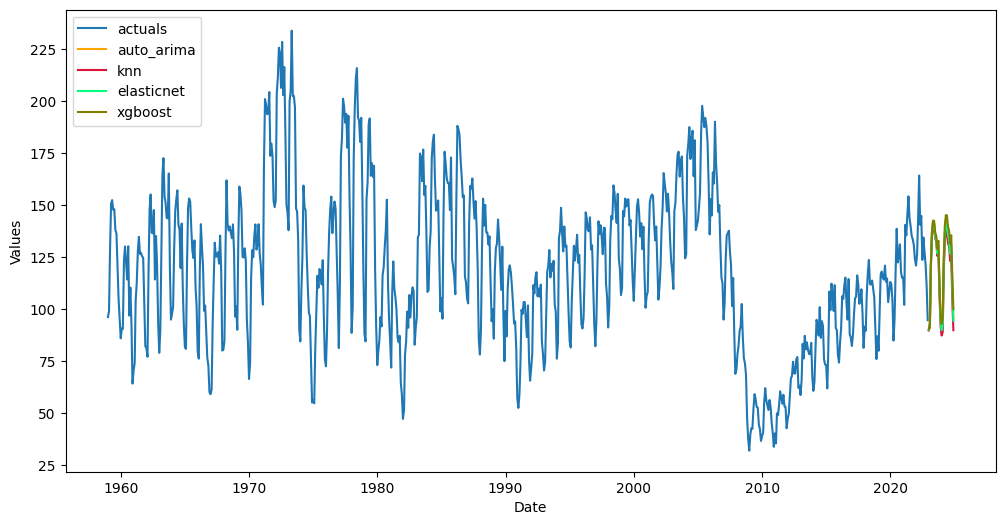

In [66]:
f.plot(order_by = 'TestSetRMSE')
plt.legend(loc='upper left')
plt.show()

These are our best-perorming models, but caution: the function that found the optimal set of transformations used the test set to optimize that decision. Because of that, we have introduced leakage and these models may not actually be as good as they appear by the out-of-sample metric.